# 01 Run Reconstruction

Before running this notebook, download the Chang'e-4 high-frequency LPR `.2B` files from the official data portal and place them in `data_raw/`. Then run all cells from top to bottom.

This notebook reads `.2B` files, displays the raw CE-4 radargram, repairs corrupted traces, detects valid segments, saves reconstructed outputs, and generates paper-style figures.


In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Put downloaded high-frequency CE-4 LPR .2B files in data_raw/, then run all cells.
INPUT_DIR = REPO_ROOT / "data_raw"
OUTPUT_DIR = REPO_ROOT / "outputs" / "reconstruction"


# Keep notebook imports synchronized with local source edits.
try:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

print("REPO_ROOT:", REPO_ROOT)
print("INPUT_DIR:", INPUT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

REPO_ROOT: e:\论文提交代码5.24\CODE_CE4
INPUT_DIR: e:\论文提交代码5.24\CODE_CE4\data_raw
OUTPUT_DIR: e:\论文提交代码5.24\CODE_CE4\outputs\reconstruction


## Preview Raw CE-4 LPR Data

This cell reads the downloaded raw `.2B` files and displays the original CE-4 LPR radargram using the same plotting style as the reconstructed result.


Raw data shape: (2048, 11725)
Source files:
 - CE4_GRAS_LPR-2B_SCI_N_20221118015001_20221119050500_0267_A.2B
 - CE4_GRAS_LPR-2B_SCI_N_20221119073501_20221119112000_0268_A.2B
 - CE4_GRAS_LPR-2B_SCI_N_20221127102001_20221128110000_0270_A.2B
Saved figure: e:\论文提交代码5.24\CODE_CE4\outputs\reconstruction\raw_ce4_lpr_preview.png


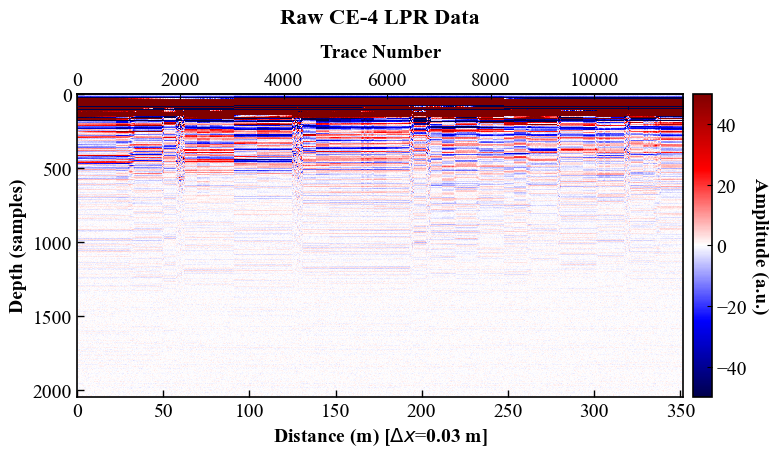

In [ ]:
from IPython.display import display
import matplotlib.pyplot as plt
import importlib
from ce4_lpr.io import read_lpr_folder
import ce4_lpr.plotting as plotting
importlib.reload(plotting)
plot_lpr_data = plotting.plot_lpr_data

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
raw_data, raw_boundaries, raw_files = read_lpr_folder(INPUT_DIR)
print("Raw data shape:", raw_data.shape)
print("Source files:")
for path in raw_files:
    print(" -", path.name)

fig, ax = plot_lpr_data(
    raw_data,
    title="Raw CE-4 LPR Data",
    lims=50,
    dx=0.03,
    figsize=(8, 4.8),
    cmap="seismic",
)
fig_path = OUTPUT_DIR / "raw_ce4_lpr_preview.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print("Saved figure:", fig_path)
display(fig)
plt.close(fig)


## Run Algorithm

In [3]:
from ce4_lpr.pipeline import ReconstructionConfig, run_reconstruction

summary = run_reconstruction(INPUT_DIR, OUTPUT_DIR, ReconstructionConfig())
summary

{'raw_shape': (2048, 11725),
 'reconstructed_shape': (2048, 871),
 'n_segments': 7,
 'n_bad_traces': 25,
 'cut_idx': 142,
 'output_dir': 'e:\\论文提交代码5.24\\CODE_CE4\\outputs\\reconstruction'}

## Check Output Files

In [4]:
import numpy as np
import pandas as pd

segments_path = OUTPUT_DIR / "detected_segments.csv"
data_path = OUTPUT_DIR / "reconstructed_valid_data.npy"
diagnostics_path = OUTPUT_DIR / "diagnostics.npz"

segments = pd.read_csv(segments_path, header=None, names=["start", "end"])
reconstructed = np.load(data_path)
diagnostics = np.load(diagnostics_path)

print("Reconstructed data shape:", reconstructed.shape)
print("Detected segment count:", len(segments))
print("Preliminary bad traces:", int(diagnostics["preliminary_mask"].sum()))
print("Released by coherence:", int(diagnostics["released_by_coherence"].sum()))
print("Final bad traces:", len(diagnostics["bad_indices"]))
display(segments)

Reconstructed data shape: (2048, 871)
Detected segment count: 7
Preliminary bad traces: 25
Released by coherence: 0
Final bad traces: 25


,start,end
0,1632,1688
1,1903,2085
2,4153,4369
3,6417,6511
4,6737,6836
5,9266,9344
6,10557,10696


## Variance Threshold Result

This figure shows the trace-wise Sobel variance, per-file dynamic threshold, and final detected valid regions.


Saved figure: e:\论文提交代码5.24\CODE_CE4\outputs\reconstruction\variance_threshold_result.png


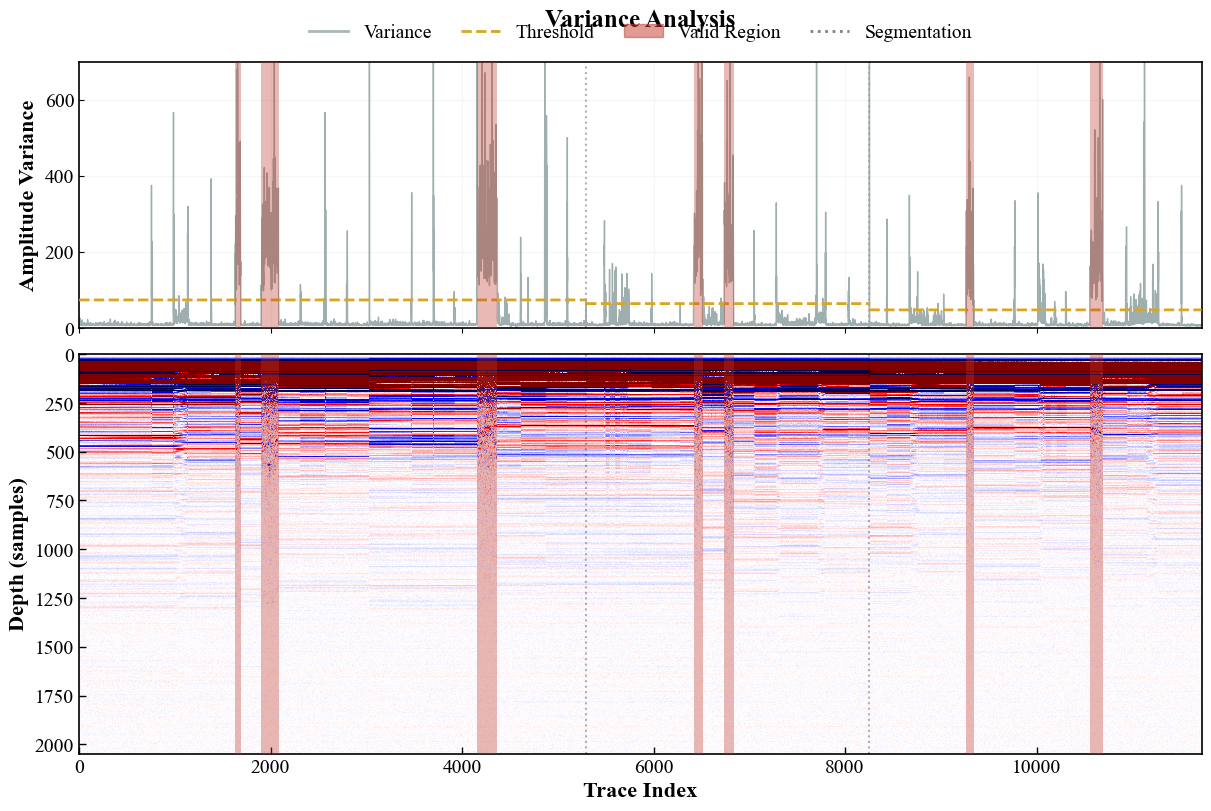

In [5]:
from IPython.display import display
import matplotlib.pyplot as plt
import importlib
import ce4_lpr.plotting as plotting
importlib.reload(plotting)
plot_variance_analysis = plotting.plot_variance_analysis

segments_for_plot = list(map(tuple, segments[["start", "end"]].to_numpy()))
variances = diagnostics["variances"]
thresholds = diagnostics["thresholds"]
boundaries = diagnostics["boundaries"]
full_data = np.load(OUTPUT_DIR / "repaired_full_data.npy")

fig, axes = plot_variance_analysis(
    variances=variances,
    boundaries=boundaries,
    thresholds=thresholds,
    segments=segments_for_plot,
    data=full_data,
    n_traces=summary["raw_shape"][1],
    ylim=(0, 700),
    title="Variance Analysis",
    figsize=(12, 8),
    data_lims=50,
)
fig_path = OUTPUT_DIR / "variance_threshold_result.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print("Saved figure:", fig_path)
display(fig)
plt.close(fig)


## Preview Reconstructed Radargram

Saved figure: e:\论文提交代码5.24\CODE_CE4\outputs\reconstruction\reconstructed_valid_data_preview.png


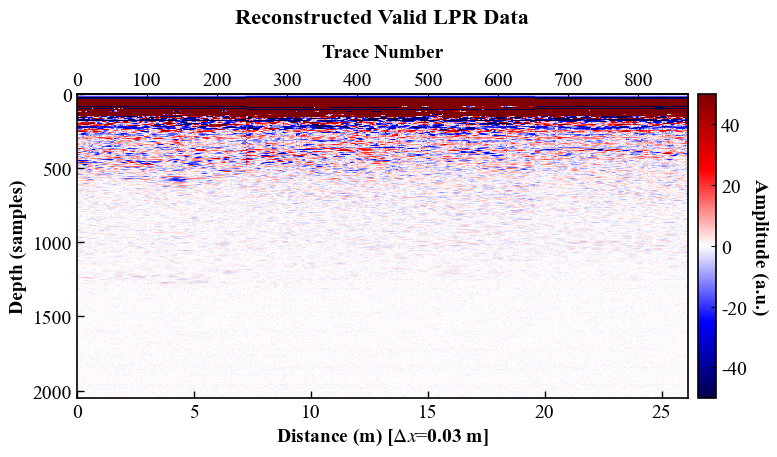

In [6]:
from IPython.display import display
import matplotlib.pyplot as plt
import importlib
import ce4_lpr.plotting as plotting
importlib.reload(plotting)
plot_lpr_data = plotting.plot_lpr_data

fig, ax = plot_lpr_data(
    reconstructed,
    title="Reconstructed Valid LPR Data",
    lims=50,
    dx=0.03,
    figsize=(8, 4.8),
    cmap="seismic",
)
fig_path = OUTPUT_DIR / "reconstructed_valid_data_preview.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print("Saved figure:", fig_path)
display(fig)
plt.close(fig)
